# Análisis Preliminar — Datos Reales Auger SD-750 + UMD (2021-2023)

Notebook de exploración a gran escala sobre el dataset procesado.  
Asume que los `.parquet` ya están generados por el pipeline paralelo.

**Contenido:**
1. Carga de todos los parquets
2. Resumen del dataset (estadísticas, flags de calidad)
3. Cobertura temporal (eventos por mes)
4. Espectro de energía por año
5. Señal UMD media vs energía
6. Perfil lateral de muones (LDF) por rango de energía
7. Mapa 2D: señal en el espacio (logE, r)
8. Evolución temporal de la calidad del detector
9. Verificación de isotropía azimutal

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
print('Imports OK')

Imports OK


## ⚙️ Configuración

> **Nota sobre los flags de rechazo:** los parquets incluyen  
> `is_sd_rejected` e `is_counter_rejected` como columnas booleanas.  
> El dataset limpio se define con `CLEAN_MASK` abajo.  
> Podés explorar los rechazados *sin* reprocesar los ADST.

In [2]:
PARQUET_DIR = '/home/lsilva/Github/parquet_datos_campo/'   # directorio con los .parquet
YEARS       = [2021, 2022, 2023]         # años procesados

# Subsets disponibles
SUBSETS = ['PhaseI', 'PhaseIISPMTPhaseIIBeta']

# ── SELECCIONÁ QUÉ SUBSET ANALIZAR EN ESTA CORRIDA ──
ACTIVE_SUBSET = 'PhaseI' 
# ACTIVE_SUBSET = 'PhaseIISPMTPhaseIIBeta'

# Cortes de análisis (aplicados en pandas, no en lectura)
CLEAN_MASK = 'not is_sd_rejected and not is_counter_rejected and module_status == "candidate"'

# Bins de energía para los análisis
E_BINS  = np.arange(17.0, 21.1, 0.25)
E_MIDS  = 0.5 * (E_BINS[:-1] + E_BINS[1:])

# Bins de distancia al core
R_BINS  = np.arange(0, 1501, 100)   # 0 a 1500 m, pasos de 100 m
R_MIDS  = 0.5 * (R_BINS[:-1] + R_BINS[1:])

print(f'Directorio: {PARQUET_DIR}')
print(f'Subset activo para análisis: {ACTIVE_SUBSET}')

Directorio: /home/lsilva/Github/parquet_datos_campo/
Subset activo para análisis: PhaseI


## 📂 Carga de datos

In [3]:
# ── Cargar todos los .parquet del subset activo ─────────────────────────
print(f'Buscando datos para el subset: {ACTIVE_SUBSET}')

# El '**' con recursive=True busca en todas las subcarpetas de año/mes automáticamente
pattern = os.path.join(PARQUET_DIR, '**', f'ADST_{ACTIVE_SUBSET}_*.parquet')
files = sorted(glob.glob(pattern, recursive=True))

print(f'Archivos encontrados: {len(files)}')

if not files:
    raise FileNotFoundError(f'No se encontraron parquets para {ACTIVE_SUBSET} en {PARQUET_DIR}')

# Cargamos año por año para mostrar progreso y detectar si falta alguno
dfs = []
for year in YEARS:
    # Filtramos los archivos que correspondan a este año particular
    year_files = [f for f in files if f'_{year}_' in os.path.basename(f)]
    
    if not year_files:
        print(f'  {year}: sin archivos')
        continue
        
    df_year = pd.concat([pd.read_parquet(f) for f in year_files], ignore_index=True)
    dfs.append(df_year)
    print(f'  {year}: {len(year_files):>3} archivos  |  {len(df_year):>8,} filas  |  {df_year["event_id"].nunique():>6,} eventos')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal para {ACTIVE_SUBSET}: {len(df):,} filas  |  {df["event_id"].nunique():,} eventos únicos')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Buscando datos para el subset: PhaseI
Archivos encontrados: 328
  2021: 269 archivos  |   862,094 filas  |  63,703 eventos
  2022:  59 archivos  |    22,692 filas  |   2,119 eventos
  2023: sin archivos

Total para PhaseI: 884,786 filas  |  65,822 eventos únicos
Memoria: 199 MB


## 📊 Resumen del dataset

In [4]:
# ── Resumen del dataset ────────────────────────────────────────────────
print('=== Dataset completo (sin filtros adicionales) ===')
print()

n_total_events  = df['event_id'].nunique()
n_total_modules = len(df)
n_counters      = df['counterId'].nunique()

print(f'Eventos únicos:            {n_total_events:>8,}')
print(f'Filas totales (módulos):   {n_total_modules:>8,}')
print(f'Counters UMD únicos:       {n_counters:>8}')
print(f'Módulos por evento (avg):  {n_total_modules/n_total_events:>8.1f}')
print()

# Flags de calidad
n_sd_rejected  = df['is_sd_rejected'].sum()
n_ctr_rejected = df['is_counter_rejected'].sum()
n_candidate    = (df['module_status'] == 'candidate').sum()

print('=== Flags de calidad (sobre total de filas) ===')
print(f'Módulos con SD rechazada:      {n_sd_rejected:>7,}  ({100*n_sd_rejected/n_total_modules:.1f}%)')
print(f'Módulos con Counter rechazado: {n_ctr_rejected:>7,}  ({100*n_ctr_rejected/n_total_modules:.1f}%)')
print(f'Módulos candidatos:            {n_candidate:>7,}  ({100*n_candidate/n_total_modules:.1f}%)')
print()

# Dataset limpio
df_clean = df.query(CLEAN_MASK).copy()
n_clean_ev = df_clean['event_id'].nunique()
print(f'=== Dataset limpio (sd_ok + counter_ok + candidate) ===')
print(f'Eventos con al menos 1 módulo limpio: {n_clean_ev:,}')
print(f'Filas limpias: {len(df_clean):,}  ({100*len(df_clean)/n_total_modules:.1f}% del total)')

=== Dataset completo (sin filtros adicionales) ===

Eventos únicos:              65,822
Filas totales (módulos):    884,786
Counters UMD únicos:             26
Módulos por evento (avg):      13.4

=== Flags de calidad (sobre total de filas) ===
Módulos con SD rechazada:      294,216  (33.3%)
Módulos con Counter rechazado: 163,356  (18.5%)
Módulos candidatos:            593,373  (67.1%)

=== Dataset limpio (sd_ok + counter_ok + candidate) ===
Eventos con al menos 1 módulo limpio: 54,551
Filas limpias: 499,558  (56.5% del total)


## 📅 Cobertura temporal

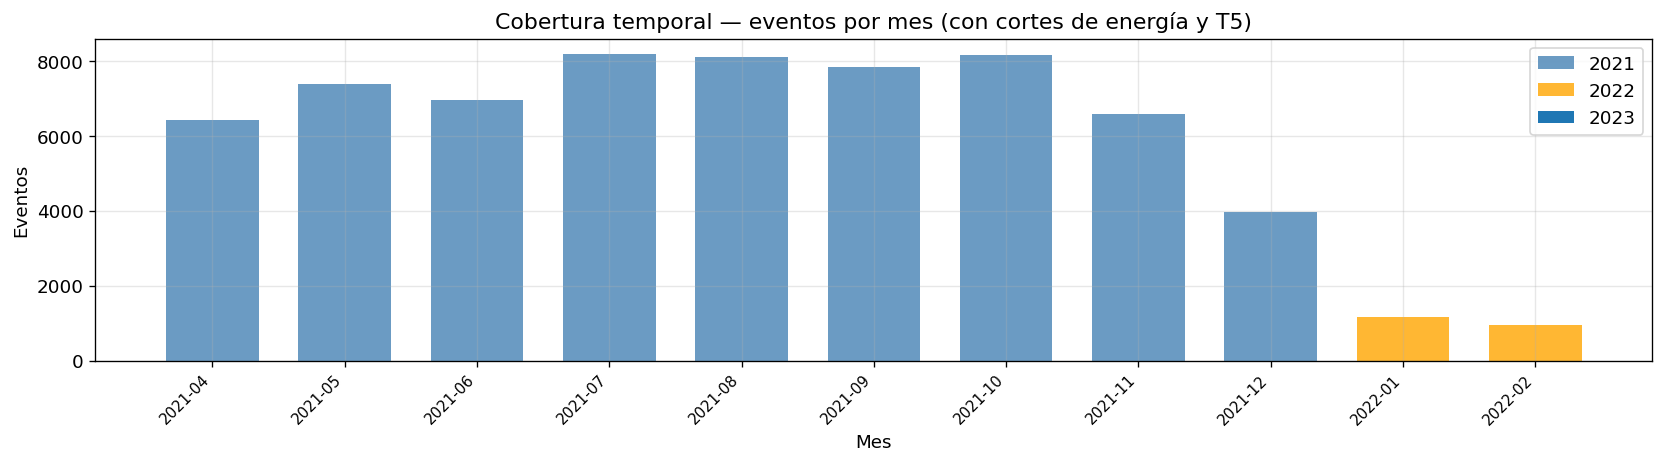

Meses con datos: 11
Promedio eventos/mes: 5984  |  min: 960  |  max: 8202


In [5]:
# ── Cobertura temporal: eventos por mes ────────────────────────────────
evts_per_event = df.drop_duplicates('event_id')[['event_id','year','month','logE_REC']].copy()
counts = evts_per_event.groupby(['year','month']).size().reset_index(name='n_events')

fig, ax = plt.subplots(figsize=(14, 4))
colors_year = {2021: 'steelblue', 2022: 'orange', 2023: 'green'}

for year in YEARS:
    sub = counts[counts['year'] == year]
    x   = [f'{year}-{m:02d}' for m in sub['month']]
    ax.bar(x, sub['n_events'], color=colors_year.get(year, 'gray'),
           label=str(year), alpha=0.8, width=0.7)

ax.set_xlabel('Mes')
ax.set_ylabel('Eventos')
ax.set_title('Cobertura temporal — eventos por mes (con cortes de energía y T5)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Meses con datos: {len(counts)}')
print(f'Promedio eventos/mes: {counts["n_events"].mean():.0f}  |  min: {counts["n_events"].min()}  |  max: {counts["n_events"].max()}')

## ⚡ Espectro de energía

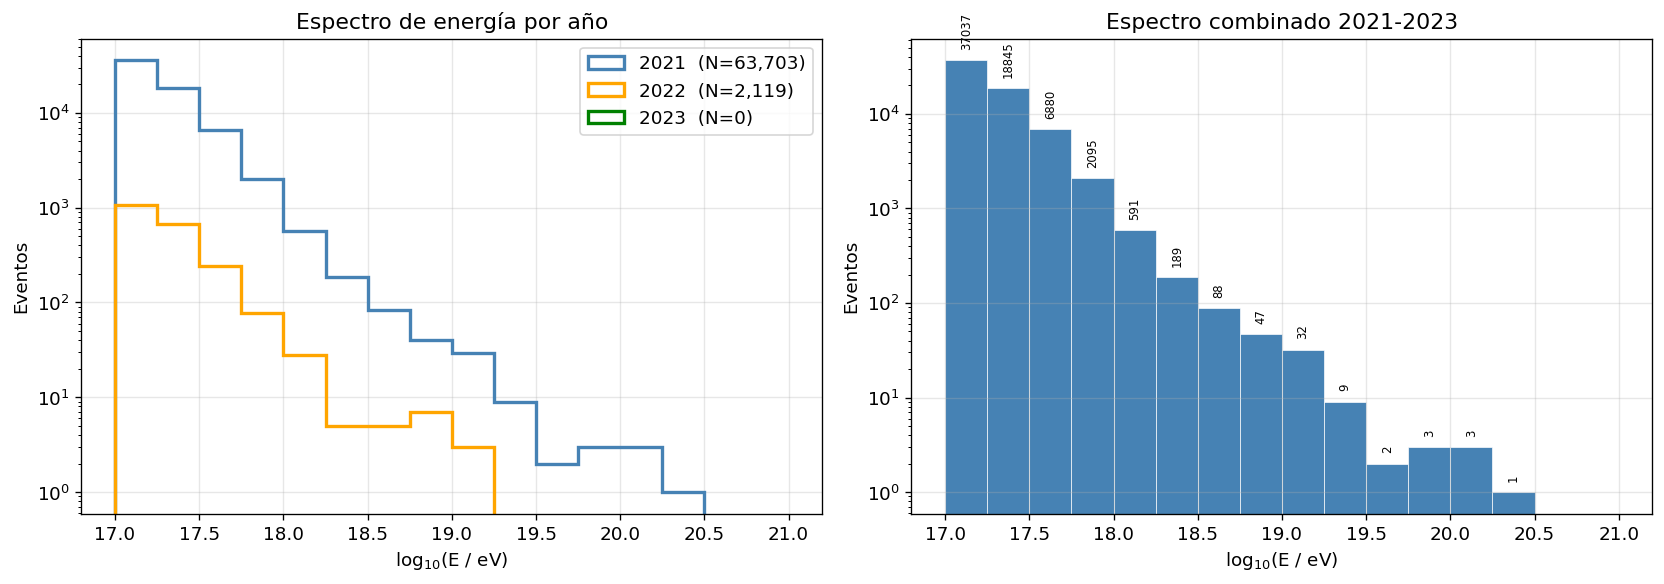

Estadísticas del espectro (dataset limpio):
  [17.00, 17.25]  N=37037
  [17.25, 17.50]  N=18845
  [17.50, 17.75]  N= 6880
  [17.75, 18.00]  N= 2095
  [18.00, 18.25]  N=  591
  [18.25, 18.50]  N=  189
  [18.50, 18.75]  N=   88
  [18.75, 19.00]  N=   47
  [19.00, 19.25]  N=   32
  [19.25, 19.50]  N=    9
  [19.50, 19.75]  N=    2
  [19.75, 20.00]  N=    3
  [20.00, 20.25]  N=    3
  [20.25, 20.50]  N=    1
  [20.50, 20.75]  N=    0
  [20.75, 21.00]  N=    0


In [6]:
# ── Espectro de energía por año ────────────────────────────────────────
events_u = df.drop_duplicates('event_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: histograma apilado por año
ax = axes[0]
for year in YEARS:
    sub = events_u[events_u['year'] == year]['logE_REC']
    ax.hist(sub, bins=E_BINS, histtype='step', lw=2,
            label=f'{year}  (N={len(sub):,})',
            color=colors_year.get(year, 'gray'))
ax.set_yscale('log')
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Espectro de energía por año')
ax.legend()

# Panel der: espectro combinado + conteo por bin
ax = axes[1]
n_per_bin, _, _ = ax.hist(events_u['logE_REC'], bins=E_BINS,
                           color='steelblue', edgecolor='white', lw=0.4)
ax.set_yscale('log')
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Espectro combinado 2021-2023')

# Anotar cada bin con el N
for mid, n in zip(E_MIDS, n_per_bin):
    if n > 0:
        ax.text(mid, n*1.3, f'{int(n)}', ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

print('Estadísticas del espectro (dataset limpio):')
for lo, hi, mid, n in zip(E_BINS[:-1], E_BINS[1:], E_MIDS, n_per_bin):
    print(f'  [{lo:.2f}, {hi:.2f}]  N={int(n):>5}')

## 🎯 Señal UMD vs energía

Promediamos `nMuones_REC` por módulo a nivel de evento,  
luego binamos por energía para ver la dependencia.

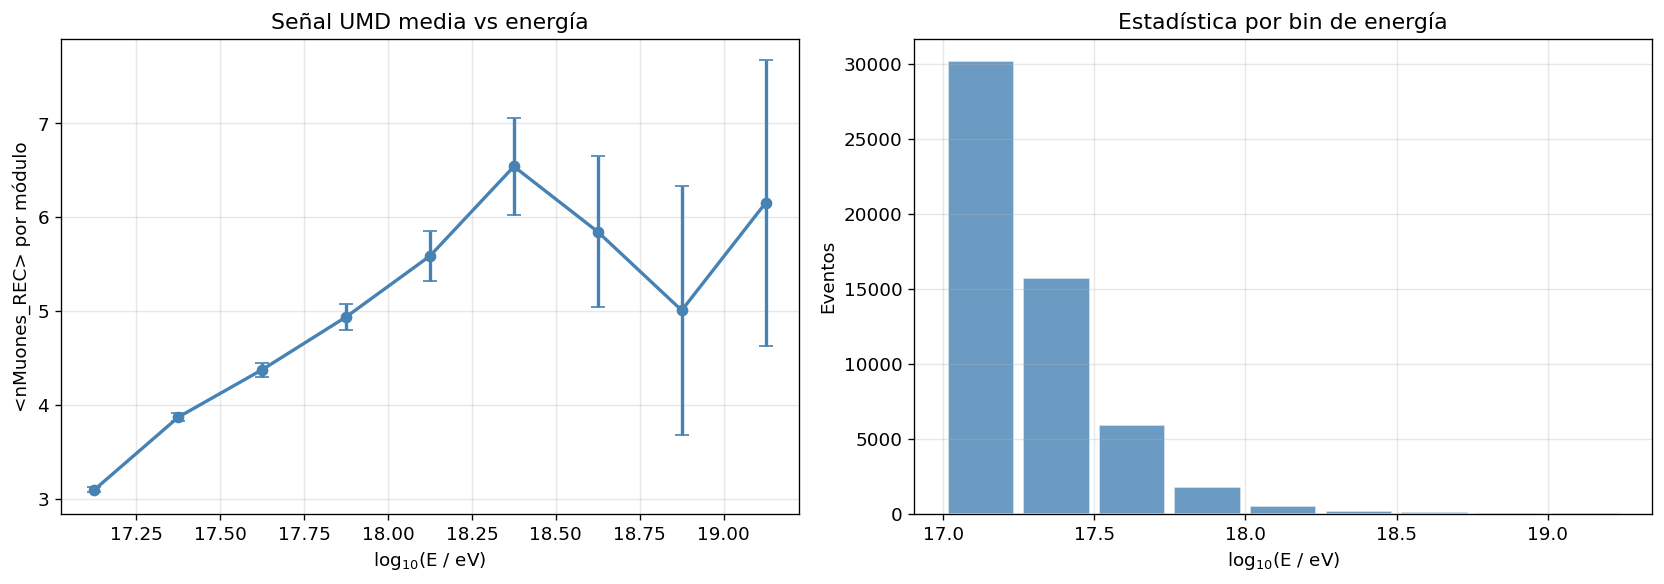

nMuones medio por módulo vs logE (bins con N >= 10):
 E_bin  n_events  nMu_mean  nMu_std  nMod_mean
17.125     30190  3.094402 4.330853   8.033289
17.375     15758  3.867852 5.219731   9.658269
17.625      5917  4.373556 5.615004  11.350684
17.875      1808  4.935594 5.821036  13.224004
18.125       533  5.585427 6.080619  14.943715
18.375       175  6.538418 6.872020  17.994286
18.625        83  5.842380 7.329939  16.469880
18.875        42  5.005145 8.598223  14.071429
19.125        27  6.150842 7.897546  16.888889


In [7]:
# ── nMuones promedio vs logE (usando dataset limpio) ──────────────────
# Agrupamos a nivel de evento (promedio de módulos por evento)
ev_level = (
    df_clean
    .groupby('event_id')
    .agg(
        logE_REC   = ('logE_REC', 'first'),
        theta_REC  = ('theta_REC', 'first'),
        year       = ('year', 'first'),
        nMu_mean   = ('nMuones_REC', 'mean'),   # promedio de módulos
        nMu_sum    = ('nMuones_REC', 'sum'),    # suma de módulos
        n_modules  = ('moduleId', 'count'),     # cuántos módulos contribuyeron
    )
    .reset_index()
)

# Binear por energía
ev_level['E_bin'] = pd.cut(ev_level['logE_REC'], bins=E_BINS, labels=E_MIDS)
stats_E = (
    ev_level
    .groupby('E_bin', observed=True)
    .agg(
        n_events    = ('event_id', 'count'),
        nMu_mean    = ('nMu_mean', 'mean'),
        nMu_std     = ('nMu_mean', 'std'),
        nMu_sum_mean = ('nMu_sum', 'mean'),
        nMod_mean   = ('n_modules', 'mean'),
    )
    .reset_index()
)
stats_E['E_bin'] = stats_E['E_bin'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mask = stats_E['n_events'] >= 10  # bins con estadística mínima
ax.errorbar(stats_E.loc[mask, 'E_bin'],
            stats_E.loc[mask, 'nMu_mean'],
            yerr=stats_E.loc[mask, 'nMu_std'] / np.sqrt(stats_E.loc[mask, 'n_events']),
            fmt='o-', color='steelblue', capsize=4, lw=2)
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('<nMuones_REC> por módulo')
ax.set_title('Señal UMD media vs energía')

ax = axes[1]
ax.bar(stats_E.loc[mask, 'E_bin'], stats_E.loc[mask, 'n_events'],
       width=0.22, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('log$_{10}$(E / eV)')
ax.set_ylabel('Eventos')
ax.set_title('Estadística por bin de energía')

plt.tight_layout()
plt.show()

print('nMuones medio por módulo vs logE (bins con N >= 10):')
print(stats_E[mask][['E_bin','n_events','nMu_mean','nMu_std','nMod_mean']].to_string(index=False))

## 📐 Perfil lateral de muones (LDF)

La LDF del UMD: cómo cae la señal con la distancia al core,  
separada por rangos de energía.

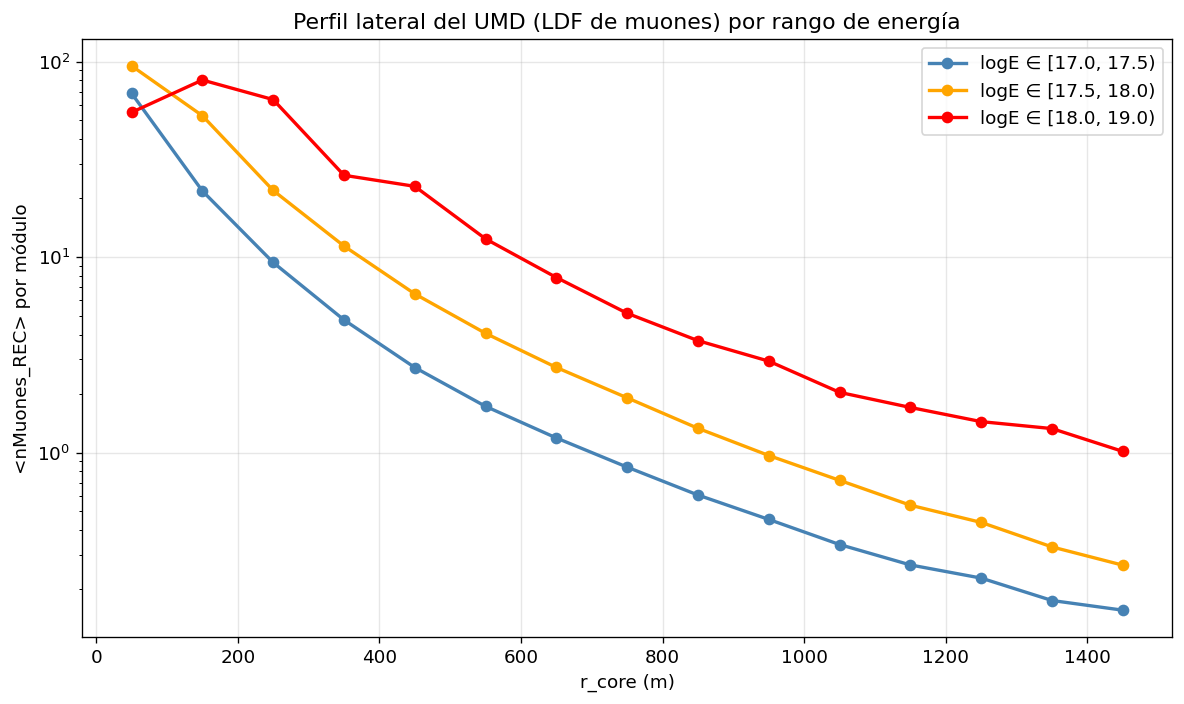

In [8]:
# ── nMuones promedio vs distancia al core (LDF del UMD) ───────────────
# Binear por r_core y por bins de energía simultáneamente
df_clean['R_bin'] = pd.cut(df_clean['r_core'], bins=R_BINS, labels=R_MIDS)
df_clean['E_bin'] = pd.cut(df_clean['logE_REC'], bins=E_BINS, labels=E_MIDS)

ldf = (
    df_clean
    .groupby(['E_bin', 'R_bin'], observed=True)
    .agg(nMu_mean=('nMuones_REC','mean'), n=('nMuones_REC','count'))
    .reset_index()
)
ldf['E_bin'] = ldf['E_bin'].astype(float)
ldf['R_bin'] = ldf['R_bin'].astype(float)

# Seleccionamos 3 rangos de energía representativos
E_ranges = [(17.0, 17.5, 'steelblue'), (17.5, 18.0, 'orange'), (18.0, 19.0, 'red')]

fig, ax = plt.subplots(figsize=(10, 6))
for e_lo, e_hi, color in E_ranges:
    sub = ldf[(ldf['E_bin'] >= e_lo) & (ldf['E_bin'] < e_hi) & (ldf['n'] >= 5)]
    sub_r = sub.groupby('R_bin').agg(nMu=('nMu_mean','mean'), n=('n','sum')).reset_index()
    ax.plot(sub_r['R_bin'], sub_r['nMu'], 'o-', color=color, lw=2,
            label=f'logE ∈ [{e_lo:.1f}, {e_hi:.1f})')

ax.set_xlabel('r_core (m)')
ax.set_ylabel('<nMuones_REC> por módulo')
ax.set_title('Perfil lateral del UMD (LDF de muones) por rango de energía')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## 🗺️ Mapa 2D de señal

In [9]:
# ── Mapa 2D: <nMuones> vs (logE, r_core) ─────────────────────────────
pivot = (
    df_clean
    .groupby(['E_bin','R_bin'], observed=True)['nMuones_REC']
    .mean()
    .unstack('R_bin')
)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(
    pivot.columns, pivot.index, pivot.values,
    cmap='YlOrRd', norm=mcolors.LogNorm(vmin=0.01, vmax=pivot.values.max()),
    shading='auto'
)
plt.colorbar(im, ax=ax, label='<nMuones_REC> por módulo')
ax.set_xlabel('r_core (m)')
ax.set_ylabel('log$_{10}$(E / eV)')
ax.set_title('Señal media del UMD en el espacio (logE, r) — 2021-2023')
plt.tight_layout()
plt.show()

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7af2989f11c0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1440x600 with 2 Axes>

## 🔍 Evolución temporal de la calidad

Usamos los flags `is_sd_rejected` e `is_counter_rejected`  
para monitorear el uptime del detector a lo largo del tiempo.

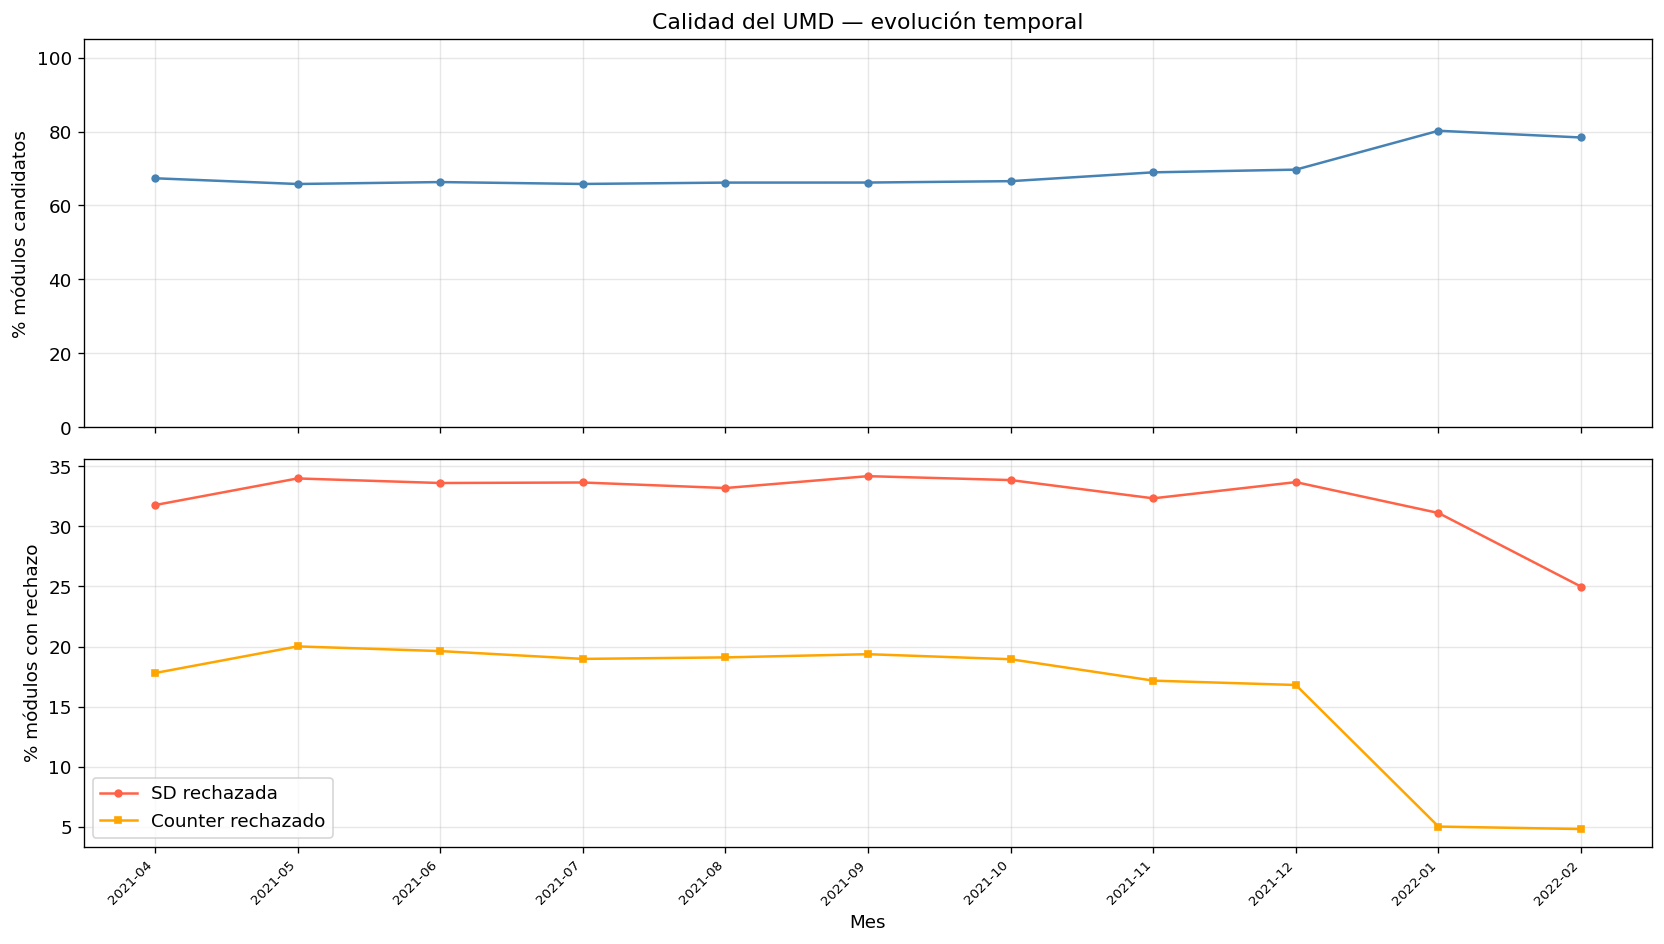

Fracción media de rechazo por año:
  2021: SD rechazada=33.4%  Counter rechazado=18.8%
  2022: SD rechazada=28.2%  Counter rechazado=4.9%
  2023: SD rechazada=nan%  Counter rechazado=nan%


In [10]:
# ── Evolución temporal de la calidad del detector ─────────────────────
# Fracción de módulos candidatos por mes → proxy del uptime del UMD
df['ym'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
quality = (
    df
    .groupby('ym')
    .apply(lambda g: pd.Series({
        'frac_candidate':      (g['module_status'] == 'candidate').mean(),
        'frac_sd_rejected':    g['is_sd_rejected'].mean(),
        'frac_ctr_rejected':   g['is_counter_rejected'].mean(),
        'n_modules':           len(g),
    }))
    .reset_index()
    .sort_values('ym')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(quality['ym'], quality['frac_candidate'] * 100, 'o-',
        color='steelblue', lw=1.5, ms=4)
ax.set_ylabel('% módulos candidatos')
ax.set_title('Calidad del UMD — evolución temporal')
ax.set_ylim(0, 105)

ax = axes[1]
ax.plot(quality['ym'], quality['frac_sd_rejected'] * 100, 'o-',
        color='tomato', lw=1.5, ms=4, label='SD rechazada')
ax.plot(quality['ym'], quality['frac_ctr_rejected'] * 100, 's-',
        color='orange', lw=1.5, ms=4, label='Counter rechazado')
ax.set_ylabel('% módulos con rechazo')
ax.set_xlabel('Mes')
ax.legend()

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Fracción media de rechazo por año:')
for year in YEARS:
    sub = df[df['year'] == year]
    fsd  = sub['is_sd_rejected'].mean() * 100
    fctr = sub['is_counter_rejected'].mean() * 100
    print(f'  {year}: SD rechazada={fsd:.1f}%  Counter rechazado={fctr:.1f}%')

## 🧭 Verificación de isotropía

El azimuth relativo `phi_plane_sp` debe ser uniforme  
(el detector es isotrópico). Si hay una asimetría, indica  
algún problema en la geometría o en los cortes.

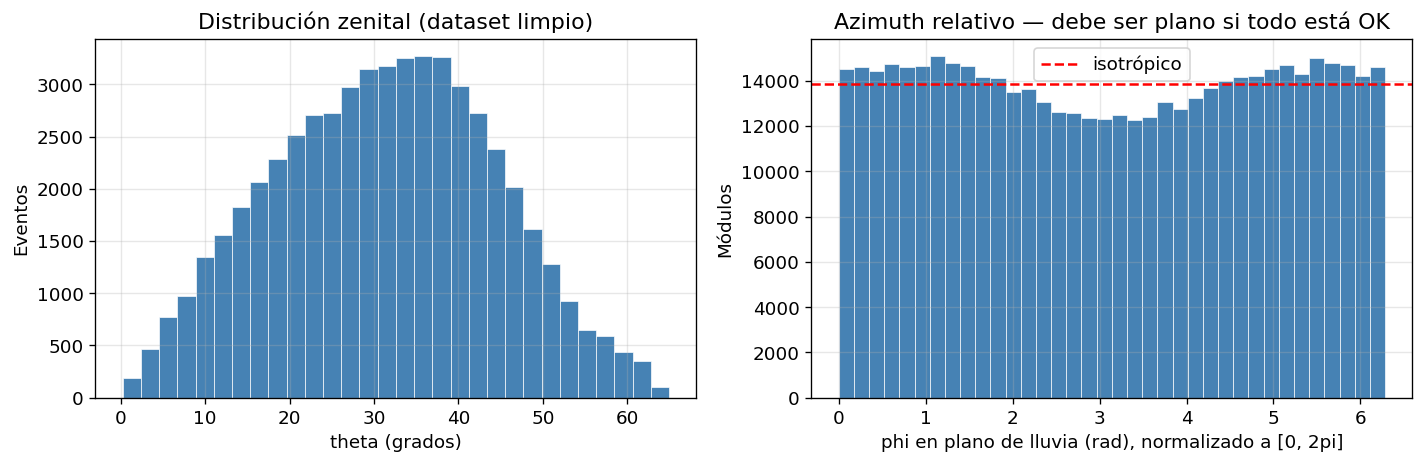

Test isotropía phi (chi2/dof): 60.25  (esperado ~1.0 si es isotrópico)


In [11]:
# ── Distribución de theta y phi_plane_sp ──────────────────────────────
events_u_clean = df_clean.drop_duplicates('event_id')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(events_u_clean['theta_REC'], bins=30,
        color='steelblue', edgecolor='white', lw=0.4)
ax.set_xlabel('theta (grados)')
ax.set_ylabel('Eventos')
ax.set_title('Distribución zenital (dataset limpio)')

ax = axes[1]
# phi_plane_sp en [-pi, pi] → lo normalizamos a [0, 2pi] para verificar isotropía
phi_norm = df_clean['phi_plane_sp'] % (2 * np.pi)
ax.hist(phi_norm, bins=36, color='steelblue', edgecolor='white', lw=0.4)
ax.axhline(len(phi_norm) / 36, color='red', lw=1.5, ls='--', label='isotrópico')
ax.set_xlabel('phi en plano de lluvia (rad), normalizado a [0, 2pi]')
ax.set_ylabel('Módulos')
ax.set_title('Azimuth relativo — debe ser plano si todo está OK')
ax.legend()

plt.tight_layout()
plt.show()

# Test de isotropía rápido
hist_phi, _ = np.histogram(phi_norm, bins=36)
chi2_iso = np.sum((hist_phi - hist_phi.mean())**2 / hist_phi.mean())
print(f'Test isotropía phi (chi2/dof): {chi2_iso/35:.2f}  (esperado ~1.0 si es isotrópico)')